## load the dataset

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("realistic_case_dataset.csv")
df

,case_type,filed_year,pending_as_of_2026,count
0,can,2016,Yes,120
1,FA,2018-05,yes,76
2,CRA,05/2023,YES,158
3,EC,2015-07-12,Yes,109
4,CPAN,Mar 2024,Yes,100
...,...,...,...,...
170,CRA,2015-06,Yes,50
171,CRR,2019-11,Yes,54
172,CRM,2021-03,Yes,73
173,PIL,2023-12,Yes,33


## pre processing step:-

### 1. remove duplicate data:-
📌 Objective

The goal of this preprocessing step is to remove duplicate entries in the dataset by merging records that have the same:

case_type
filed_year
pending_as_of_2026

and summing their count values.

Example (Before Preprocessing)
case_type	filed_year	pending_as_of_2026	count
A	2024	Yes	200
A	2024	Yes	100

These rows represent the same category and should be combined.

### Solution Approach

We perform grouping and aggregation using the Python library pandas.

Key Idea:
Group identical records using:
case_type
filed_year
pending_as_of_2026
Aggregate (sum) the count column.

### Output (After Preprocessing)
case_type	filed_year	pending_as_of_2026	count
A	2024	Yes	300

In [59]:
import pandas as pd

# Load dataset
# df = pd.read_csv("cases_updated.csv")

# Group and merge duplicates
df_cleaned = df.groupby(
    ["case_type", "filed_year", "pending_as_of_2026"],
    as_index=False
)["count"].sum()

# Save cleaned dataset
df_cleaned.to_csv("cases_merged.csv", index=False)

# Print sample output
print(df_cleaned.head())

  case_type  filed_year pending_as_of_2026  count
0        AP     05/2019                Yes    166
1        AP     2016-03                Yes    662
2        AP       2017                 Yes   1111
3        AP       2019                 Yes     71
4        AP  2019-03-03                Yes    296


In [60]:
import pandas as pd
from dateutil.relativedelta import relativedelta

# -----------------------------------------------
# LOAD
# -----------------------------------------------
df = pd.read_csv("realistic_case_dataset.csv")

current_date = pd.to_datetime("2026-04-01")

# -----------------------------------------------
# STEP 1: Clean pending column
# -----------------------------------------------
df["pending_as_of_2026"] = df["pending_as_of_2026"].str.strip().str.upper()
df = df[df["pending_as_of_2026"] == "YES"].copy()

# -----------------------------------------------
# STEP 2: Parse filed_year robustly
# -----------------------------------------------
def parse_filed_date(val):
    if pd.isnull(val):
        return pd.NaT

    val = str(val).strip()

    # Float-style year: "2016.0"
    if val.endswith(".0"):
        val = val[:-2]

    # Pure 4-digit year → Jan 1
    if val.isdigit() and len(val) == 4:
        return pd.to_datetime(f"01-01-{val}", dayfirst=True)

    # MM/YYYY or MM-YYYY (e.g. "05/2023", "2018-05")
    # Rewrite YYYY-MM → MM-YYYY so dayfirst parse works
    import re
    if re.match(r"^\d{4}-\d{2}$", val):          # "2018-05"
        val = val[5:] + "-" + val[:4]             # → "05-2018"
    if re.match(r"^\d{2}/\d{4}$", val):          # "05/2023"
        val = val[:2] + "-" + val[3:]             # → "05-2023"
    if re.match(r"^\d{2}-\d{4}$", val):          # "05-2023" after rewrite
        return pd.to_datetime("01-" + val, dayfirst=True)

    # Everything else: full dates, "Mar 2024", "June 2016", "2016-09-10"
    try:
        return pd.to_datetime(val, dayfirst=True)
    except Exception:
        return pd.NaT

df["filed_date_parsed"] = df["filed_year"].apply(parse_filed_date)

# -----------------------------------------------
# STEP 3: Formatted display column
# -----------------------------------------------
df["filed_year_clean"] = df["filed_date_parsed"].apply(
    lambda dt: dt.strftime("%d-%m-%Y") if not pd.isnull(dt) else None
)

# -----------------------------------------------
# STEP 4: Pending duration (human-readable)
# -----------------------------------------------
def calc_pending(dt):
    if pd.isnull(dt):
        return None
    diff = relativedelta(current_date, dt)
    return f"{diff.years}y {diff.months}m {diff.days}d"

df["yr_pending"] = df["filed_date_parsed"].apply(calc_pending)

# -----------------------------------------------
# STEP 5: Numeric years pending (for charts)
# -----------------------------------------------
df["years_pending"] = df["filed_date_parsed"].apply(
    lambda dt: round((current_date - dt).days / 365.25, 2) if not pd.isnull(dt) else None
)

# -----------------------------------------------
# STEP 6: Drop intermediate column & save
# -----------------------------------------------
df.drop(columns=["filed_date_parsed"], inplace=True)
df.to_csv("final_preprocessed_cases.csv", index=False)

# -----------------------------------------------
# VERIFY
# -----------------------------------------------
print(f"Total rows: {len(df)}")
print(f"NaN in filed_year_clean: {df['filed_year_clean'].isna().sum()}")
print(f"NaN in yr_pending:       {df['yr_pending'].isna().sum()}")
print()
print(df[["case_type", "filed_year", "filed_year_clean", "yr_pending", "years_pending"]].head(15).to_string())

Total rows: 175
NaN in filed_year_clean: 0
NaN in yr_pending:       0

   case_type  filed_year filed_year_clean  yr_pending  years_pending
0        can        2016       01-01-2016   10y 3m 0d          10.25
1         FA     2018-05       01-05-2018   7y 11m 0d           7.92
2        CRA     05/2023       01-05-2023   2y 11m 0d           2.92
3         EC  2015-07-12       07-12-2015  10y 3m 25d          10.32
4       CPAN    Mar 2024       01-03-2024    2y 1m 0d           2.08
5        CRR       2023        01-01-2023    3y 3m 0d           3.25
6         WP     2019-11       01-11-2019    6y 5m 0d           6.41
7        PIL     07/2017       01-07-2017    8y 9m 0d           8.75
8         SA  2017-03-15       15-03-2017   9y 0m 17d           9.05
9        MAT   June 2016       01-06-2016   9y 10m 0d           9.83
10       CAN       2020        01-01-2020    6y 3m 0d           6.25
11       CAN     2020-08       01-08-2020    5y 8m 0d           5.66
12       CRA     02/2016       0

C:\Users\User\AppData\Local\Temp\ipykernel_23056\1188511455.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(val, dayfirst=True)


In [61]:
# Round to nearest integer
df["years_pending"] = df["years_pending"].round().astype(int)

In [62]:
df.to_csv("cleaned_data.csv")
df.head()

,case_type,filed_year,pending_as_of_2026,count,filed_year_clean,yr_pending,years_pending
0,can,2016,YES,120,01-01-2016,10y 3m 0d,10
1,FA,2018-05,YES,76,01-05-2018,7y 11m 0d,8
2,CRA,05/2023,YES,158,01-05-2023,2y 11m 0d,3
3,EC,2015-07-12,YES,109,07-12-2015,10y 3m 25d,10
4,CPAN,Mar 2024,YES,100,01-03-2024,2y 1m 0d,2


In [63]:
df = pd.read_csv("cleaned_data.csv")

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import json


def generate_interactive_3d_plot(df: pd.DataFrame) -> None:
    """
    Generate an interactive 3D visualization of pending court cases.

    Approach:
        1. Data Filtering:
            - Retain only pending cases for focused backlog analysis.

        2. Feature Engineering:
            - Compute 'years_pending' from filing year.
            - Encode categorical case types into numeric indices for plotting.

        3. Visual Encoding:
            - X-axis → Case types (categorical → numeric mapping)
            - Y-axis → Years pending
            - Z-axis → Case count (height of bars)

        4. Rendering Strategy:
            - Use Plotly Mesh3d to construct cuboid bars for full control
              over geometry, lighting, and hover behavior.

        5. Color Mapping:
            - Assign consistent colors per case type for visual distinction.

        6. Interactivity:
            - Dropdown filter for years pending
            - Button controls for zoom and reset
            - Custom JavaScript injection for multi-select case type filtering

        7. Output:
            - Export as standalone HTML file for browser-based interaction

    Args:
        df (pd.DataFrame): Dataset containing:
            - pending_as_of_2026 (str)
            - filed_year (int)
            - case_type (str)
            - count (int)

    Returns:
        None: Saves output as 'pending_cases_3d.html'
    """

    case_types = sorted(df["case_type"].unique())       # Controls X-axis ordering
    years_list = sorted(df["years_pending"].unique())   # Controls dropdown filter

    case_map = {c: i for i, c in enumerate(case_types)}
    df["case_type_num"] = df["case_type"].map(case_map)

    # -------------------- Color Strategy --------------------

    palette = [
        "#5C7AEA", "#E05C5C", "#2CB67D", "#FF9F1C",
        "#A259FF", "#00B4D8", "#F4845F", "#43AA8B"
    ]  # Modify colors here

    color_map = {
        ct: palette[i % len(palette)]  # Cycles if case types exceed palette
        for i, ct in enumerate(case_types)
    }

    # -------------------- 3D Bar Construction --------------------

    def make_bar(x0, y0, z0, w, d, h, color, label, yp_val):
        """Create a 3D cuboid bar using Mesh3d."""

        x1, y1, z1 = x0 + w, y0 + d, z0 + h

        return go.Mesh3d(
            x=[x0,x1,x1,x0, x0,x1,x1,x0],
            y=[y0,y0,y1,y1, y0,y0,y1,y1],
            z=[z0,z0,z0,z0, z1,z1,z1,z1],
            i=[0,0,0,1,4,4,4,5,0,1,2,3],
            j=[1,2,4,5,5,6,7,6,3,2,3,7],
            k=[2,3,5,6,6,7,3,7,4,5,6,4],

            color=color,                   # Bar color
            opacity=0.90,                 # Transparency (lower = more transparent)
            flatshading=True,             # Set False for smoother lighting

            lighting=dict(
                ambient=0.85,             # Brightness
                diffuse=0.6,              # Light spread
                specular=0.1              # Reflection
            ),

            showscale=False,
            name=label,
            hovertemplate=(
                f"<b>{label}</b><br>"
                f"Years pending: {yp_val}<br>"
                f"Count: {int(round(h))}<extra></extra>"
            ),
        )

    BAR_W, BAR_D = 0.8, 0.6              # Adjust for bar thickness

    traces, trace_meta = [], []

    # -------------------- Trace Generation --------------------

    for _, row in df.iterrows():
        traces.append(make_bar(
            x0=row["case_type_num"] - BAR_W/2,
            y0=row["years_pending"] - BAR_D/2,
            z0=0,
            w=BAR_W,
            d=BAR_D,
            h=row["count"],
            color=color_map[row["case_type"]],
            label=row["case_type"],
            yp_val=row["years_pending"],
        ))

        trace_meta.append((row["case_type"], row["years_pending"]))

    n_bar = len(traces)

    # -------------------- Legend --------------------

    for ct in case_types:
        traces.append(go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(color=color_map[ct], size=10, symbol="square"),
            name=ct,
            showlegend=True,
        ))
        trace_meta.append((ct, None))

    # -------------------- Camera Controls --------------------

    DEFAULT_CAMERA = dict(eye=dict(x=1.7, y=-1.7, z=1.1))  # Initial view

    def scale_eye(factor):
        """Adjust zoom level."""
        e = DEFAULT_CAMERA["eye"]
        return dict(eye=dict(
            x=e["x"] * factor,  # <1 zoom in, >1 zoom out
            y=e["y"] * factor,
            z=e["z"] * factor
        ))

    # -------------------- Filtering --------------------

    def vis_yp(selected="All"):
        return [
            True if i >= n_bar
            else (selected == "All" or yp == selected)
            for i, (_, yp) in enumerate(trace_meta)
        ]

    yp_buttons = [dict(label="All years", method="restyle", args=[{"visible": vis_yp()}])]

    for yp in years_list:
        yp_buttons.append(dict(
            label=f"{yp} yr{'s' if yp != 1 else ''}",
            method="restyle",
            args=[{"visible": vis_yp(yp)}],
        ))
        # Case type buttons — mirrors yp_buttons pattern
    def vis_ct(sel_ct="All", sel_yp="All"):
        return [
            True if i >= n_bar
            else (sel_ct == "All" or ct == sel_ct) and (sel_yp == "All" or yp == sel_yp)
            for i, (ct, yp) in enumerate(trace_meta)
        ]

    ct_buttons = [dict(label="All types", method="restyle", args=[{"visible": vis_ct()}])]
    for ct in case_types:
        ct_buttons.append(dict(
            label=ct,
            method="restyle",
            args=[{"visible": vis_ct(sel_ct=ct)}],
        ))

# In layout updatemenus, add alongside yp dropdown:
dict(type="dropdown", x=0.28, y=1.12, buttons=ct_buttons),
    # -------------------- Layout --------------------

    short_labels = [ct[:9] + "…" if len(ct) > 9 else ct for ct in case_types]

    layout = go.Layout(
        title=dict(text="Pending cases by type and years pending", x=0.5),

        scene=dict(
            xaxis=dict(
                title="Case type",
                tickvals=list(range(len(case_types))),
                ticktext=short_labels
            ),
            yaxis=dict(title="Years pending"),
            zaxis=dict(title="Case count"),
            camera=DEFAULT_CAMERA,
            aspectmode="manual",
            aspectratio=dict(x=2.0, y=1.2, z=1.0)
        ),

        legend=dict(title_text="Case types"),

        margin=dict(l=20, r=20, t=130, b=20),

        updatemenus=[
            dict(type="dropdown", x=0.0, y=1.12, buttons=yp_buttons),
            dict(
                type="buttons",
                x=0.0, y=1.04,
                buttons=[
                    dict(label="Zoom in",  method="relayout", args=[{"scene.camera": scale_eye(0.75)}]),
                    dict(label="Zoom out", method="relayout", args=[{"scene.camera": scale_eye(1.33)}]),
                    dict(label="Reset",    method="relayout", args=[{"scene.camera": DEFAULT_CAMERA}]),
                ],
            ),
        ],
    )

    fig = go.Figure(data=traces, layout=layout)

    # -------------------- Export --------------------

    fig.write_html("pending_cases_3d.html", config={"scrollZoom": True})
    fig.show()
    print("Saved → pending_cases_3d.html")

In [43]:
generate_interactive_3d_plot(df)

Saved → pending_cases_3d.html


## Matplotlib static 3D bar visualization of pending court cases.

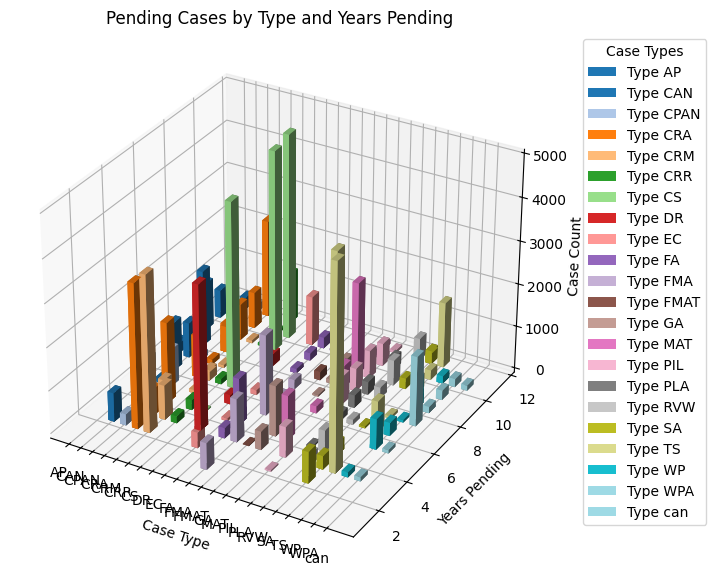

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

'''
    This cell processes court case data to display the distribution
    of pending cases across different case types and years pending.
    The visualization is created using Matplotlib's 3D plotting.

    Args:
        df (pd.DataFrame): Input dataset containing court case records.
            Expected columns:
                - pending_as_of_2026 (str): "Yes"/"No" indicating pending status
                - filed_year (int): Year the case was filed
                - case_type (str): Category/type of the case
                - count (int): Number of cases

    output:
        Displays a 3D bar chart.

    Notes:
        - The visualization is static and does not support interactivity.
        - Suitable for small to medium datasets.
'''

# Encode case types
case_types = sorted(df["case_type"].unique())
case_map = {c:i for i,c in enumerate(case_types)}
df["case_type_num"] = df["case_type"].map(case_map)

# X = case types
x = df["case_type_num"].values

# Y = years pending
y = df["years_pending"].values

# Z height
top = df["count"].values
bottom = np.zeros_like(top)

width = depth = 0.5

# Create color map for case types
colors_list = plt.cm.tab20(np.linspace(0,1,len(case_types)))
color_map = {case_types[i]:colors_list[i] for i in range(len(case_types))}

# Assign colors
colors = df["case_type"].map(color_map)

# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(x, y, bottom, width, depth, top, shade=True, color=colors)

# Axis labels
ax.set_xlabel("Case Type")
ax.set_ylabel("Years Pending")
ax.set_zlabel("Case Count")

# Show actual labels
ax.set_xticks(range(len(case_types)))
ax.set_xticklabels(case_types)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color_map[t], label=f"Type {t}") 
    for t in case_types
]

ax.legend(
    handles=legend_elements,
    title="Case Types",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("Pending Cases by Type and Years Pending")

plt.show()



## Bubble Plot Visualization (Static Approach)

### Overview
This approach attempts to visualize pending court cases using a 2D bubble plot, where multiple dimensions of the dataset are encoded into a single chart.

### Approach

1. **Data Representation**
   - X-axis → Case types (categorical)
   - Y-axis → Years pending (numerical)
   - Bubble size → Number of cases
   - Bubble color → Case type

2. **Encoding Strategy**
   - Each point represents a group of cases for a specific case type and duration.
   - Larger bubbles indicate higher case counts.
   - Color differentiation helps distinguish case categories.

3. **Annotation Strategy**
   - Each bubble is labeled with the exact case count to improve interpretability.
   - Labels are centered within bubbles for readability.

4. **Visualization Design**
   - Seaborn scatterplot is used for simplicity and quick implementation.
   - Gridlines and legends are added for clarity.

### Limitations

- **Bubble Overlapping**  
  Data points with similar case types and years pending overlap significantly, making individual values difficult to distinguish.

- **Reduced Readability**  
  The visualization requires additional effort to interpret, especially when multiple bubbles are clustered together.

- **Ineffective Representation of Density**  
  Overlapping bubbles obscure true case distribution, leading to potential misinterpretation.

- **Limited Clarity for Decision-Making**  
  The lack of visual separation reduces usability for stakeholders such as judges who require quick and clear insights.

### Conclusion
While simple and quick to implement, the bubble plot is not suitable for complex judicial datasets. It lacks clarity and scalability, leading to the adoption of interactive 3D visualization in subsequent implementations.


In [ ]:
df = pd.read_csv("realistic_case_dataset.csv")

In [ ]:
CURRENT_YEAR = 2026

df["years_pending"] = CURRENT_YEAR - df["filed_year"]

In [ ]:
pending_cases = df[df["pending_as_of_2026"] == "Yes"]
# pending_cases = df[df["pending_as_of_2026"] == "No"]

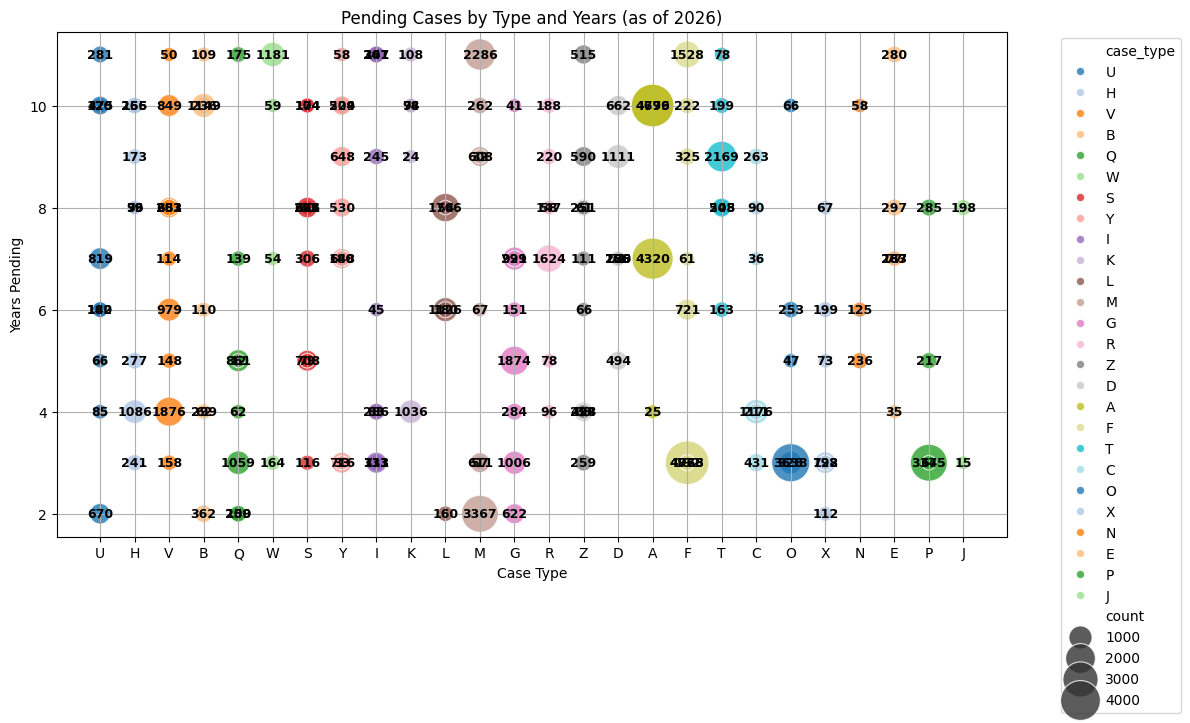

In [ ]:
plt.figure(figsize=(12,7))  # Controls overall plot size (increase for better spacing with many categories)

# -------------------- Bubble Plot Construction --------------------

ax = sns.scatterplot(
    data=pending_cases,
    x="case_type",          # X-axis: categorical case types (can become cluttered if too many)
    y="years_pending",      # Y-axis: numerical duration of pending cases

    hue="case_type",        # Assigns distinct color per case type (helps visual grouping)
    size="count",           # Bubble size proportional to number of cases
    sizes=(100,1000),       # Min/max bubble size (adjust for better visibility or scaling)

    palette="tab20",        # Color palette (change for different visual themes)
    alpha=0.8,              # Transparency (lower if overlap is high)
    legend=True             # Enables legend for color and size interpretation
)

# -------------------- Annotation (Count Labels) --------------------

for _, row in pending_cases.iterrows():
    ax.text(
        row["case_type"],       # X position (aligned with category)
        row["years_pending"],   # Y position

        str(row["count"]),      # Text displayed (case count)

        ha="center",            # Horizontal alignment (centered in bubble)
        va="center",            # Vertical alignment
        fontsize=9,             # Adjust for readability
        color="black",          # Text color (change if background overlaps)
        weight="bold"           # Emphasis for visibility
    )

# -------------------- Plot Configuration --------------------

plt.title("Pending Cases by Type and Years (as of 2026)")  # Main title
plt.xlabel("Case Type")                                   # X-axis label
plt.ylabel("Years Pending")                               # Y-axis label

plt.legend(
    bbox_to_anchor=(1.05,1),  # Moves legend outside plot (prevents overlap)
    loc="upper left"
)

plt.grid(True)  # Adds gridlines for easier value estimation

plt.tight_layout()  # Adjusts layout to prevent clipping of labels/legend

# -------------------- Render --------------------

plt.show()  # Displays static visualization (no interactivity)

## Pie Chart Visualization (Distribution-Based Approach)

### Overview
This approach visualizes the distribution of pending court cases across different case types using a pie (donut-style) chart.

### Approach

1. **Data Filtering**
   - Retain only pending cases to focus on backlog analysis.

2. **Aggregation Strategy**
   - Group data by case type.
   - Sum total number of cases for each category.

3. **Visual Encoding**
   - Each slice represents a case type.
   - Slice size → Proportional to total case count.
   - Labels → Show case type, percentage, and absolute count.

4. **Design Choice**
   - Donut-style pie chart (using a hole) improves readability.
   - Suitable for understanding proportional distribution at a glance.

### Limitations

- **Loss of Temporal Information**  
  Does not capture how long cases have been pending.

- **Limited Dimensionality**  
  Only shows distribution by case type; ignores other critical factors.

- **Not Suitable for Detailed Analysis**  
  Cannot represent relationships between multiple variables.

- **Scalability Issues**  
  Becomes cluttered when there are many case types.

### Conclusion
While effective for understanding overall distribution, the pie chart lacks depth and analytical capability, making it insufficient for detailed judicial data analysis.

In [ ]:
import pandas as pd
import plotly.express as px

# -------------------- Data Filtering --------------------

# Retain only pending cases for analysis
pending_cases = df[df["pending_as_of_2026"] == "Yes"]  # Modify condition if including other statuses


# -------------------- Aggregation --------------------

# Group by case type and compute total case count
case_summary = (
    pending_cases
    .groupby("case_type")["count"]
    .sum()
    .reset_index()
)  # Change aggregation (e.g., mean) if required


# -------------------- Pie Chart Construction --------------------

fig = px.pie(
    case_summary,
    values="count",        # Slice size proportional to number of cases
    names="case_type",     # Category labels

    title="Distribution of Pending Cases by Case Type",

    hole=0.2               # 0 → full pie, >0 → donut (increase for more hollow center)
)


# -------------------- Trace Customization --------------------

fig.update_traces(
    textinfo="label+percent+value"  # Controls displayed info (modify as needed)
)


# -------------------- Render --------------------

fig.show()  # Displays interactive pie chart